# Notebook 01 — Exploring the TripAdvisor European restaurants dataset.


# Goal:
understand the structure of the raw data, count Lyon restaurants, and identify which columns are usable.

In [3]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Project paths
NOTEBOOK_DIR = Path.cwd()  # current working directory = notebooks/
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data dir: {DATA_RAW}")
print(f"Files in raw/: {[f.name for f in DATA_RAW.iterdir() if f.is_file()]}")

Project root: C:\Users\busar\Desktop\connoisseur
Raw data dir: C:\Users\busar\Desktop\connoisseur\data\raw
Files in raw/: ['.gitkeep', 'tripadvisor-european-restaurants.zip', 'tripadvisor_european_restaurants.csv']


In [26]:
# Adjust this if your filename is different — check the output of cell 1
CSV_FILENAME = "tripadvisor_european_restaurants.csv"

csv_path = DATA_RAW / CSV_FILENAME

# Load the full dataset. low_memory=False avoids pandas' chunked-inference 
# warnings on mixed-type columns.
df = pd.read_csv(csv_path, low_memory=False)

print(f"Loaded {len(df):,} rows and {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Loaded 1,083,397 rows and 42 columns
Memory usage: 1918.9 MB


In [27]:
# What columns do we have?
df.columns.tolist()

['restaurant_link',
 'restaurant_name',
 'original_location',
 'country',
 'region',
 'province',
 'city',
 'address',
 'latitude',
 'longitude',
 'claimed',
 'awards',
 'popularity_detailed',
 'popularity_generic',
 'top_tags',
 'price_level',
 'price_range',
 'meals',
 'cuisines',
 'special_diets',
 'features',
 'vegetarian_friendly',
 'vegan_options',
 'gluten_free',
 'original_open_hours',
 'open_days_per_week',
 'open_hours_per_week',
 'working_shifts_per_week',
 'avg_rating',
 'total_reviews_count',
 'default_language',
 'reviews_count_in_default_language',
 'excellent',
 'very_good',
 'average',
 'poor',
 'terrible',
 'food',
 'service',
 'value',
 'atmosphere',
 'keywords']

In [28]:
df.head(3)

,restaurant_link,restaurant_name,original_location,country,region,province,city,address,latitude,longitude,...,excellent,very_good,average,poor,terrible,food,service,value,atmosphere,keywords
0,g10001637-d10002227,Le 147,"[""Europe"", ""France"", ""Nouvelle-Aquitaine"", ""Ha...",France,Nouvelle-Aquitaine,Haute-Vienne,Saint-Jouvent,"10 Maison Neuve, 87510 Saint-Jouvent France",45.961674,1.169131,...,2.0,0.0,0.0,0.0,0.0,4.0,4.5,4.0,NaN,NaN
1,g10001637-d14975787,Le Saint Jouvent,"[""Europe"", ""France"", ""Nouvelle-Aquitaine"", ""Ha...",France,Nouvelle-Aquitaine,Haute-Vienne,Saint-Jouvent,"16 Place de l Eglise, 87510 Saint-Jouvent France",45.957040,1.205480,...,2.0,2.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2,g10002858-d4586832,Au Bout du Pont,"[""Europe"", ""France"", ""Centre-Val de Loire"", ""B...",France,Centre-Val de Loire,Berry,Rivarennes,"2 rue des Dames, 36800 Rivarennes France",46.635895,1.386133,...,3.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN


In [29]:
# How many restaurants in Lyon?
lyon_filter = df["city"].str.lower() == "lyon"
lyon_count = lyon_filter.sum()
print(f"Restaurants in Lyon: {lyon_count}")

# Also check the country to make sure it's French Lyon (not US or other)
lyon_df = df[lyon_filter]
print(f"\nCountries of these 'Lyon' restaurants:")
print(lyon_df["country"].value_counts())

Restaurants in Lyon: 2930

Countries of these 'Lyon' restaurants:
country
France    2930
Name: count, dtype: int64


In [30]:
print(f"Lyon (France) restaurants: {len(lyon_df):,}")
print(f"Memory usage: {lyon_df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Lyon (France) restaurants: 2,930
Memory usage: 5.2 MB


In [31]:
# Inspect missing values for each column
missing = lyon_df.isnull().sum()
total = len(lyon_df)

# Build a summary
summary = pd.DataFrame({
    "missing": missing,
    "missing_pct": (missing / total * 100).round(1),
    "dtype": lyon_df.dtypes,
})

# Sort by missing percentage
summary = summary.sort_values("missing_pct")
summary

,missing,missing_pct,dtype
restaurant_link,0,0.0,object
restaurant_name,0,0.0,object
original_location,0,0.0,object
country,0,0.0,object
region,0,0.0,object
province,0,0.0,object
city,0,0.0,object
address,0,0.0,object
claimed,0,0.0,object
vegetarian_friendly,0,0.0,object


count    2665.000000
mean        4.009756
std         0.751811
min         1.000000
25%         3.500000
50%         4.000000
75%         4.500000
max         5.000000
Name: avg_rating, dtype: float64


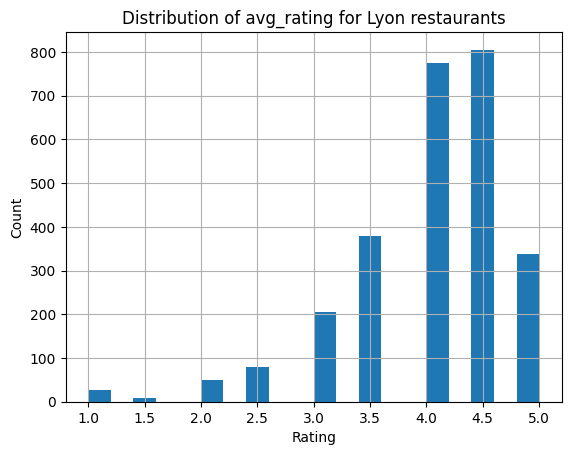

In [32]:
# Find the rating column. Common names: 'avg_rating', 'rating', 'food_rating'
# Adapt this to whatever your dataset uses
rating_col = "avg_rating"  # change if needed

if rating_col in lyon_df.columns:
    print(lyon_df[rating_col].describe())
    
    # Histogram
    lyon_df[rating_col].dropna().hist(bins=20)
    plt.title(f"Distribution of {rating_col} for Lyon restaurants")
    plt.xlabel("Rating")
    plt.ylabel("Count")
    plt.show()
else:
    print(f"Column '{rating_col}' not found. Available columns:")
    print([c for c in lyon_df.columns if "rating" in c.lower()])

count    2665.000000
mean      114.042026
std       257.089119
min         1.000000
25%         9.000000
50%        33.000000
75%       116.000000
max      7817.000000
Name: total_reviews_count, dtype: float64


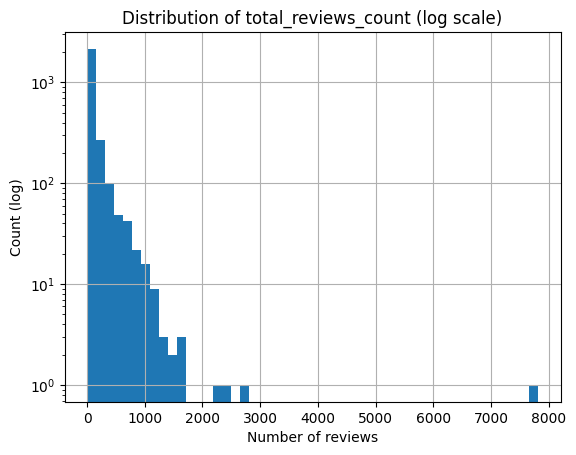

In [33]:
# Find the review count column
review_col = "total_reviews_count"  # adapt if needed

if review_col in lyon_df.columns:
    print(lyon_df[review_col].describe())
    
    # Log scale because distribution is heavily skewed
    lyon_df[review_col].dropna().hist(bins=50, log=True)
    plt.title(f"Distribution of {review_col} (log scale)")
    plt.xlabel("Number of reviews")
    plt.ylabel("Count (log)")
    plt.show()
else:
    print(f"Column '{review_col}' not found. Candidates:")
    print([c for c in lyon_df.columns if "review" in c.lower()])

In [34]:
# Save Lyon restaurants to processed/ for the next notebook to use
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
output_path = DATA_PROCESSED / "lyon_restaurants_raw.csv"

lyon_df.to_csv(output_path, index=False)
print(f"Saved {len(lyon_df):,} Lyon restaurants to {output_path}")
print(f"File size: {output_path.stat().st_size / 1e6:.1f} MB")

Saved 2,930 Lyon restaurants to C:\Users\busar\Desktop\connoisseur\data\processed\lyon_restaurants_raw.csv
File size: 1.8 MB
